## Diffusion-Enhanced Brain Tumour Segmentation with Explainable Representation Analysis

In [ ]:
!pip install -q nibabel

In [ ]:
import os
import gc
import math
import random
from glob import glob
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split


In [ ]:
CFG = {
    "seed": 42,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "img_size": 256,
    "batch_size": 8,
    "num_workers": 2,
    "epochs_denoiser": 2,
    "epochs_stage1": 6,
    "epochs_stage2": 6,
    "lr": 2e-4,
    "weight_decay": 1e-5,
    "val_ratio": 0.15,
    "max_subjects": None,          
    "max_slices_per_subject": 48,  
    "tta_passes": 4,               
    "threshold": 0.5,
    "prior_weight": 0.20,
    "uncertainty_weight": 0.25,
    "stage2_feedback_weight": 0.50,
    "amp": True,
}

DATA_ROOT = "/kaggle/input"  

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(CFG["seed"])
DEVICE = CFG["device"]
print("DEVICE:", DEVICE)

DEVICE: cuda


In [6]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/anamreyaz
/kaggle/input/datasets/anamreyaz/archive-3
/kaggle/input/datasets/anamreyaz/archive-3/Brain Metastases
/kaggle/input/datasets/anamreyaz/archive-3/Brain Metastases/test
/kaggle/input/datasets/anamreyaz/archive-3/Brain Metastases/test/Mets_026
/kaggle/input/datasets/anamreyaz/archive-3/Brain Metastases/test/Mets_012
/kaggle/input/datasets/anamreyaz/archive-3/Brain Metastases/test/Mets_051
/kaggle/input/datasets/anamreyaz/archive-3/Brain Metastases/test/Mets_047
/kaggle/input/datasets/anamreyaz/archive-3/Brain Metastases/test/Mets_030
/kaggle/input/datasets/anamreyaz/archive-3/Brain Metastases/test/Mets_042
/kaggle/input/datasets/anamreyaz/archive-3/Brain Metastases/test/Mets_025
/kaggle/input/datasets/anamreyaz/archive-3/Brain Metastases/test/Mets_007
/kaggle/input/datasets/anamreyaz/archive-3/Brain Metastases/test/Mets_048
/kaggle/input/datasets/anamreyaz/archive-3/Brain Metastases/test/Mets_009
/kaggle/input/datasets

In [ ]:
import os

BASE_DIR = "/kaggle/input/datasets/anamreyaz/archive-3/Brain Metastases"

TRAIN_ROOT = os.path.join(BASE_DIR, "train")
TEST_ROOT  = os.path.join(BASE_DIR, "test")

print("TRAIN_ROOT:", TRAIN_ROOT)
print("TEST_ROOT :", TEST_ROOT)

print("TRAIN exists:", os.path.exists(TRAIN_ROOT))
print("TEST exists :", os.path.exists(TEST_ROOT))

assert os.path.exists(TRAIN_ROOT), f"Training folder not found: {TRAIN_ROOT}"
assert os.path.exists(TEST_ROOT), f"Testing folder not found: {TEST_ROOT}"


TRAIN_ROOT: /kaggle/input/datasets/anamreyaz/archive-3/Brain Metastases/train
TEST_ROOT : /kaggle/input/datasets/anamreyaz/archive-3/Brain Metastases/test
TRAIN exists: True
TEST exists : True


In [ ]:
from glob import glob
import os

train_subjects = sorted(glob(os.path.join(TRAIN_ROOT, "Mets_*")))
test_subjects  = sorted(glob(os.path.join(TEST_ROOT, "Mets_*")))

print("Number of train subjects:", len(train_subjects))
print("Number of test subjects :", len(test_subjects))

print("\nSample train subject:", train_subjects[0])

sample_files = sorted(glob(os.path.join(train_subjects[0], "*")))
print("Number of files in sample subject:", len(sample_files))

print("\nFirst 20 files:")
for f in sample_files[:20]:
    print(os.path.basename(f))

Number of train subjects: 105
Number of test subjects : 51

Sample train subject: /kaggle/input/datasets/anamreyaz/archive-3/Brain Metastases/train/Mets_001
Number of files in sample subject: 750

First 20 files:
bravo_001_slice_0.jpg
bravo_001_slice_1.jpg
bravo_001_slice_10.jpg
bravo_001_slice_100.jpg
bravo_001_slice_101.jpg
bravo_001_slice_102.jpg
bravo_001_slice_103.jpg
bravo_001_slice_104.jpg
bravo_001_slice_105.jpg
bravo_001_slice_106.jpg
bravo_001_slice_107.jpg
bravo_001_slice_108.jpg
bravo_001_slice_109.jpg
bravo_001_slice_11.jpg
bravo_001_slice_110.jpg
bravo_001_slice_111.jpg
bravo_001_slice_112.jpg
bravo_001_slice_113.jpg
bravo_001_slice_114.jpg
bravo_001_slice_115.jpg


Total jpg slices: 750
Image size: (369, 369)
Image mode: RGB


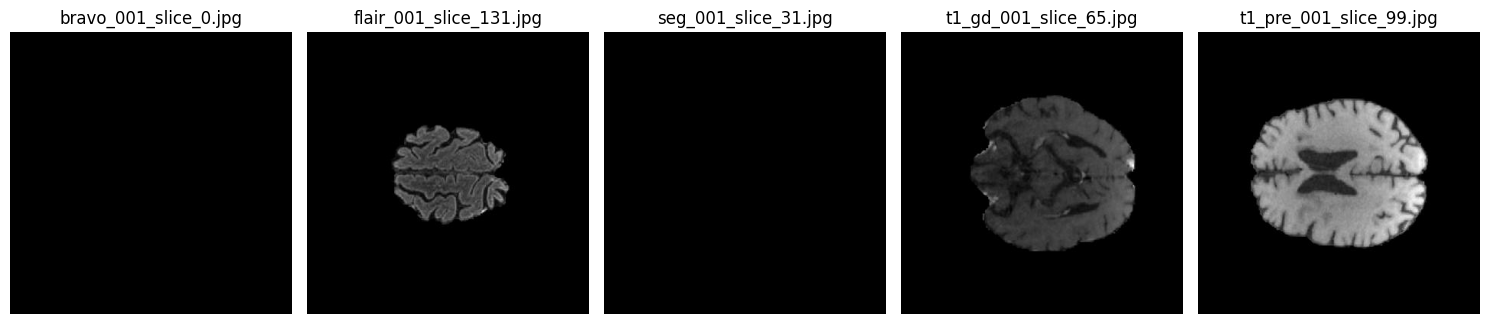

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

sample_subject = train_subjects[0]
sample_files = sorted(glob(os.path.join(sample_subject, "*.jpg")))

print("Total jpg slices:", len(sample_files))

img = Image.open(sample_files[0])
print("Image size:", img.size)
print("Image mode:", img.mode)

plt.figure(figsize=(15, 5))

for i, idx in enumerate([0, len(sample_files)//4, len(sample_files)//2, 3*len(sample_files)//4, len(sample_files)-1]):
    plt.subplot(1, 5, i+1)
    im = Image.open(sample_files[idx]).convert("L")
    plt.imshow(im, cmap="gray")
    plt.title(os.path.basename(sample_files[idx]))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import cv2

def load_grayscale(path):
    img = Image.open(path).convert("L")
    arr = np.array(img).astype(np.float32)
    return arr

def normalize_percentile(x, lower=1, upper=99):
    lo = np.percentile(x, lower)
    hi = np.percentile(x, upper)
    x = np.clip(x, lo, hi)
    x = (x - lo) / (hi - lo + 1e-8)
    return x.astype(np.float32)

def resize_if_needed(x, size=256, is_mask=False):
    if x.shape[0] == size and x.shape[1] == size:
        return x
    interp = cv2.INTER_NEAREST if is_mask else cv2.INTER_LINEAR
    return cv2.resize(x, (size, size), interpolation=interp)

def extract_slice_number(path):
    name = os.path.basename(path)
    # bravo_001_slice_123.jpg -> 123
    num = name.split("_slice_")[-1].split(".")[0]
    return int(num)

In [ ]:
import re
from glob import glob
import os

def extract_slice_number(path):
    name = os.path.basename(path)
    m = re.search(r"_slice_(\d+)\.", name)
    return int(m.group(1)) if m else -1

def get_train_subjects_multimodal(root):
    subjects = []

    for sdir in sorted(glob(os.path.join(root, "Mets_*"))):
        all_jpgs = sorted(glob(os.path.join(sdir, "*.jpg")))

        bravo  = sorted([f for f in all_jpgs if os.path.basename(f).startswith("bravo_")],  key=extract_slice_number)
        flair  = sorted([f for f in all_jpgs if os.path.basename(f).startswith("flair_")],  key=extract_slice_number)
        seg    = sorted([f for f in all_jpgs if os.path.basename(f).startswith("seg_")],    key=extract_slice_number)
        t1_gd  = sorted([f for f in all_jpgs if os.path.basename(f).startswith("t1_gd_")],  key=extract_slice_number)
        t1_pre = sorted([f for f in all_jpgs if os.path.basename(f).startswith("t1_pre_")], key=extract_slice_number)

        lengths = [len(bravo), len(flair), len(seg), len(t1_gd), len(t1_pre)]

        if min(lengths) == 0:
            print(f"Skipping TRAIN {sdir} because one modality is missing: {lengths}")
            continue

        min_len = min(lengths)

        subjects.append({
            "id": os.path.basename(sdir),
            "bravo": bravo[:min_len],
            "flair": flair[:min_len],
            "seg": seg[:min_len],
            "t1_gd": t1_gd[:min_len],
            "t1_pre": t1_pre[:min_len],
        })

    return subjects


def get_test_subjects_multimodal(root):
    subjects = []

    for sdir in sorted(glob(os.path.join(root, "Mets_*"))):
        all_jpgs = sorted(glob(os.path.join(sdir, "*.jpg")))

        bravo  = sorted([f for f in all_jpgs if os.path.basename(f).startswith("bravo_")],  key=extract_slice_number)
        flair  = sorted([f for f in all_jpgs if os.path.basename(f).startswith("flair_")],  key=extract_slice_number)
        t1_gd  = sorted([f for f in all_jpgs if os.path.basename(f).startswith("t1_gd_")],  key=extract_slice_number)
        t1_pre = sorted([f for f in all_jpgs if os.path.basename(f).startswith("t1_pre_")], key=extract_slice_number)

        lengths = [len(bravo), len(flair), len(t1_gd), len(t1_pre)]

        if min(lengths) == 0:
            print(f"Skipping TEST {sdir} because one modality is missing: {lengths}")
            continue

        min_len = min(lengths)

        subjects.append({
            "id": os.path.basename(sdir),
            "bravo": bravo[:min_len],
            "flair": flair[:min_len],
            "t1_gd": t1_gd[:min_len],
            "t1_pre": t1_pre[:min_len],
        })

    return subjects


train_subjects_info = get_train_subjects_multimodal(TRAIN_ROOT)
test_subjects_info  = get_test_subjects_multimodal(TEST_ROOT)

print("Train subjects loaded:", len(train_subjects_info))
print("Test subjects loaded :", len(test_subjects_info))

print("\nExample TRAIN subject:", train_subjects_info[0]["id"])
print("Train slices:", len(train_subjects_info[0]["bravo"]))

print("\nExample TEST subject:", test_subjects_info[0]["id"])
print("Test slices:", len(test_subjects_info[0]["bravo"]))

Train subjects loaded: 105
Test subjects loaded : 51

Example TRAIN subject: Mets_001
Train slices: 150

Example TEST subject: Mets_001
Test slices: 150


In [ ]:
def build_train_slice_records(subjects, max_slices_per_subject=None):
    records = []

    for sub in subjects:
        total = len(sub["bravo"])
        indices = list(range(total))

        if max_slices_per_subject is not None and total > max_slices_per_subject:
            indices = np.linspace(0, total - 1, max_slices_per_subject).astype(int).tolist()

        for i in indices:
            records.append({
                "subject_id": sub["id"],
                "slice_idx": i,
                "bravo": sub["bravo"][i],
                "flair": sub["flair"][i],
                "seg": sub["seg"][i],
                "t1_gd": sub["t1_gd"][i],
                "t1_pre": sub["t1_pre"][i],
            })

    return records


def build_test_slice_records(subjects, max_slices_per_subject=None):
    records = []

    for sub in subjects:
        total = len(sub["bravo"])
        indices = list(range(total))

        if max_slices_per_subject is not None and total > max_slices_per_subject:
            indices = np.linspace(0, total - 1, max_slices_per_subject).astype(int).tolist()

        for i in indices:
            records.append({
                "subject_id": sub["id"],
                "slice_idx": i,
                "bravo": sub["bravo"][i],
                "flair": sub["flair"][i],
                "t1_gd": sub["t1_gd"][i],
                "t1_pre": sub["t1_pre"][i],
            })

    return records


train_records = build_train_slice_records(train_subjects_info, max_slices_per_subject=128)
test_records  = build_test_slice_records(test_subjects_info, max_slices_per_subject=128)

print("Total train slice records:", len(train_records))
print("Total test slice records :", len(test_records))

print("\nExample train record:")
print(train_records[0])

print("\nExample test record:")
print(test_records[0])

Total train slice records: 13440
Total test slice records : 6528

Example train record:
{'subject_id': 'Mets_001', 'slice_idx': 0, 'bravo': '/kaggle/input/datasets/anamreyaz/archive-3/Brain Metastases/train/Mets_001/bravo_001_slice_0.jpg', 'flair': '/kaggle/input/datasets/anamreyaz/archive-3/Brain Metastases/train/Mets_001/flair_001_slice_0.jpg', 'seg': '/kaggle/input/datasets/anamreyaz/archive-3/Brain Metastases/train/Mets_001/seg_001_slice_0.jpg', 't1_gd': '/kaggle/input/datasets/anamreyaz/archive-3/Brain Metastases/train/Mets_001/t1_gd_001_slice_0.jpg', 't1_pre': '/kaggle/input/datasets/anamreyaz/archive-3/Brain Metastases/train/Mets_001/t1_pre_001_slice_0.jpg'}

Example test record:
{'subject_id': 'Mets_001', 'slice_idx': 0, 'bravo': '/kaggle/input/datasets/anamreyaz/archive-3/Brain Metastases/test/Mets_001/bravo_001_slice_0.jpg', 'flair': '/kaggle/input/datasets/anamreyaz/archive-3/Brain Metastases/test/Mets_001/flair_001_slice_0.jpg', 't1_gd': '/kaggle/input/datasets/anamreyaz/ar

In [ ]:
from sklearn.model_selection import train_test_split

subject_ids = sorted(list(set([r["subject_id"] for r in train_records])))
train_ids, val_ids = train_test_split(subject_ids, test_size=0.15, random_state=42)

train_records_split = [r for r in train_records if r["subject_id"] in train_ids]
val_records_split   = [r for r in train_records if r["subject_id"] in val_ids]

print("Train subjects:", len(train_ids))
print("Val subjects  :", len(val_ids))
print("Train slices  :", len(train_records_split))
print("Val slices    :", len(val_records_split))

Train subjects: 89
Val subjects  : 16
Train slices  : 11392
Val slices    : 2048


In [ ]:
import numpy as np
import cv2
from PIL import Image

def load_grayscale(path):
    img = Image.open(path).convert("L")
    arr = np.array(img).astype(np.float32)
    return arr

def normalize_percentile(x, lower=1, upper=99):
    lo = np.percentile(x, lower)
    hi = np.percentile(x, upper)
    x = np.clip(x, lo, hi)
    x = (x - lo) / (hi - lo + 1e-8)
    return x.astype(np.float32)

def resize_if_needed(x, size=256, is_mask=False):
    if x.shape[0] == size and x.shape[1] == size:
        return x
    interp = cv2.INTER_NEAREST if is_mask else cv2.INTER_LINEAR
    return cv2.resize(x, (size, size), interpolation=interp)

def to_binary_mask(x):
    return (x > 127).astype(np.float32)

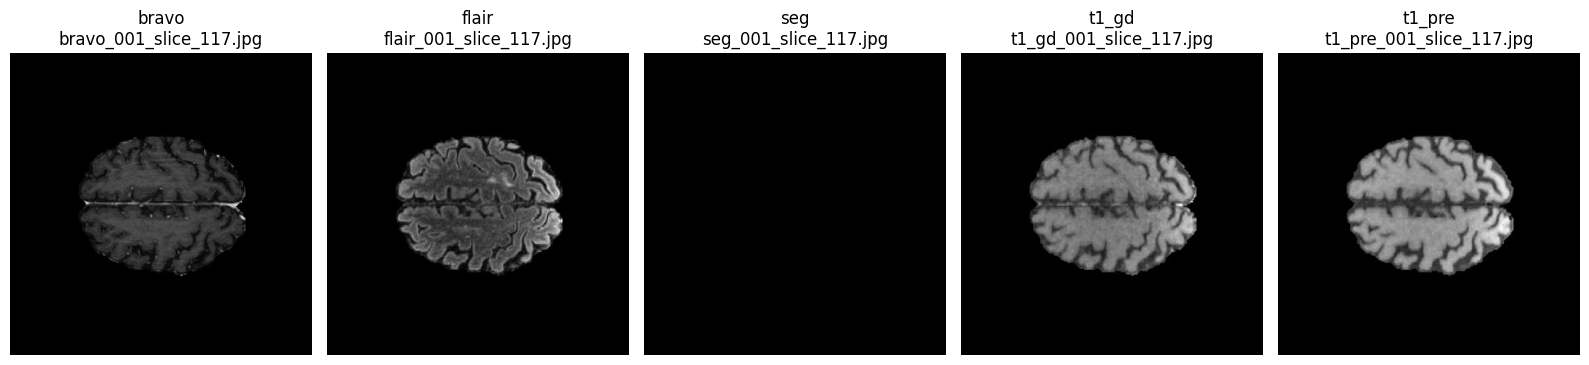

In [ ]:
import matplotlib.pyplot as plt
import os

sample = train_records[100]

imgs = {
    "bravo": load_grayscale(sample["bravo"]),
    "flair": load_grayscale(sample["flair"]),
    "seg": load_grayscale(sample["seg"]),
    "t1_gd": load_grayscale(sample["t1_gd"]),
    "t1_pre": load_grayscale(sample["t1_pre"]),
}

plt.figure(figsize=(16, 4))
for i, (k, v) in enumerate(imgs.items(), 1):
    plt.subplot(1, 5, i)
    plt.imshow(v, cmap="gray")
    plt.title(f"{k}\n{os.path.basename(sample[k])}")
    plt.axis("off")
plt.tight_layout()
plt.show()

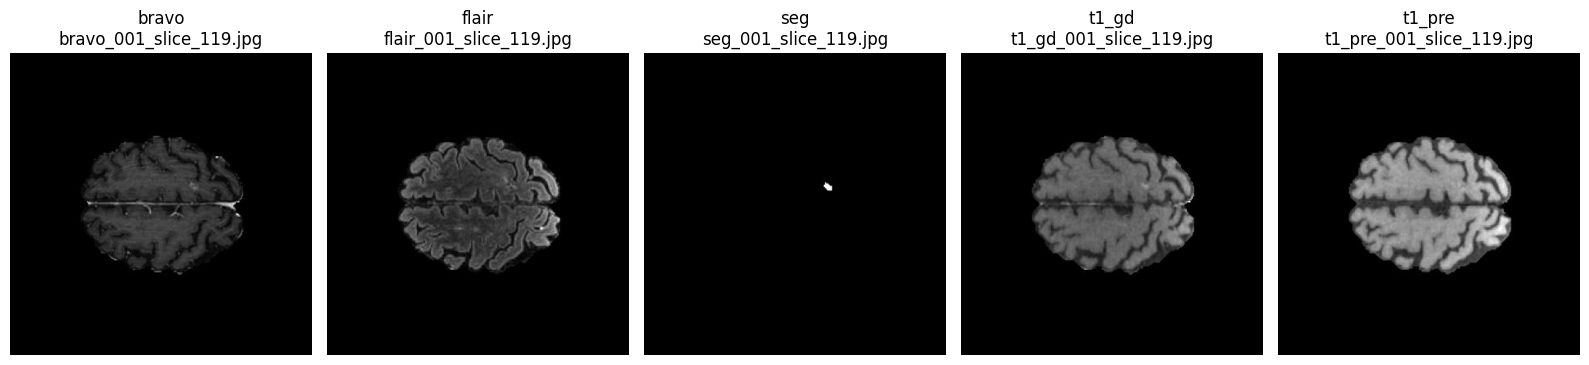

In [ ]:
import matplotlib.pyplot as plt
import os

sample = train_records[102]

imgs = {
    "bravo": load_grayscale(sample["bravo"]),
    "flair": load_grayscale(sample["flair"]),
    "seg": load_grayscale(sample["seg"]),
    "t1_gd": load_grayscale(sample["t1_gd"]),
    "t1_pre": load_grayscale(sample["t1_pre"]),
}

plt.figure(figsize=(16, 4))
for i, (k, v) in enumerate(imgs.items(), 1):
    plt.subplot(1, 5, i)
    plt.imshow(v, cmap="gray")
    plt.title(f"{k}\n{os.path.basename(sample[k])}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
def compute_prior_map(bravo, flair, t1_gd, t1_pre):
    bravo  = normalize_percentile(bravo)
    flair  = normalize_percentile(flair)
    t1_gd  = normalize_percentile(t1_gd)
    t1_pre = normalize_percentile(t1_pre)

    enhance = np.clip(t1_gd - t1_pre, 0, 1)

    flair_blur = cv2.GaussianBlur(flair, (5, 5), 0)
    flair_abn = np.clip(flair - flair_blur + 0.5, 0, 1)

    bravo_blur = cv2.GaussianBlur(bravo, (5, 5), 0)
    bravo_edge = np.clip(bravo - bravo_blur + 0.5, 0, 1)

    prior = 0.50 * enhance + 0.30 * flair_abn + 0.20 * bravo_edge
    prior = cv2.GaussianBlur(prior.astype(np.float32), (5, 5), 0)
    prior = np.clip(prior, 0, 1)

    return prior.astype(np.float32)

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        emb = math.log(10000) / (half - 1)
        emb = torch.exp(torch.arange(half, device=t.device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        emb = torch.cat([emb.sin(), emb.cos()], dim=1)
        return emb

class TinyDenoiser(nn.Module):
    def __init__(self, in_ch=4, base=24):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(base),
            nn.Linear(base, base),
            nn.ReLU(inplace=True),
        )
        self.conv1 = nn.Conv2d(in_ch, base, 3, padding=1)
        self.conv2 = nn.Conv2d(base, base, 3, padding=1)
        self.conv3 = nn.Conv2d(base, in_ch, 3, padding=1)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x, t):
        temb = self.time_mlp(t).unsqueeze(-1).unsqueeze(-1)
        h = self.act(self.conv1(x) + temb)
        h = self.act(self.conv2(h))
        out = self.conv3(h)
        return out

class SimpleNoiseSchedule:
    def __init__(self, steps=50, device="cpu"):
        self.steps = steps
        betas = torch.linspace(1e-4, 0.02, steps, device=device)
        alphas = 1. - betas
        self.alpha_hat = torch.cumprod(alphas, dim=0)
        self.device = device

    def sample_timesteps(self, n):
        return torch.randint(0, self.steps, (n,), device=self.device)

    def q_sample(self, x0, t):
        noise = torch.randn_like(x0)
        a_hat = self.alpha_hat[t].view(-1, 1, 1, 1)
        xt = torch.sqrt(a_hat) * x0 + torch.sqrt(1 - a_hat) * noise
        return xt, noise

DEVICE: cuda


In [ ]:
from torch.utils.data import Dataset

IMG_SIZE = 256

class MetsSegDataset(Dataset):
    def __init__(self, records, mode="denoise", denoiser=None, schedule=None):
        self.records = records
        self.mode = mode
        self.denoiser = denoiser
        self.schedule = schedule

    def __len__(self):
        return len(self.records)

    @torch.no_grad()
    def enhance_with_denoiser(self, x4):
        if self.denoiser is None or self.schedule is None:
            return x4
        self.denoiser.eval()
        xt = x4.unsqueeze(0).to(DEVICE)
        t = torch.full((1,), 8, device=DEVICE, dtype=torch.long)
        pred_noise = self.denoiser(xt, t)
        enh = xt - 0.15 * pred_noise
        return enh.squeeze(0).cpu()

    def __getitem__(self, idx):
        r = self.records[idx]

        bravo  = resize_if_needed(load_grayscale(r["bravo"]),  IMG_SIZE)
        flair  = resize_if_needed(load_grayscale(r["flair"]),  IMG_SIZE)
        t1_gd  = resize_if_needed(load_grayscale(r["t1_gd"]),  IMG_SIZE)
        t1_pre = resize_if_needed(load_grayscale(r["t1_pre"]), IMG_SIZE)
        seg    = resize_if_needed(load_grayscale(r["seg"]),    IMG_SIZE, is_mask=True)

        bravo  = normalize_percentile(bravo)
        flair  = normalize_percentile(flair)
        t1_gd  = normalize_percentile(t1_gd)
        t1_pre = normalize_percentile(t1_pre)
        seg    = to_binary_mask(seg)

        prior = compute_prior_map(bravo, flair, t1_gd, t1_pre)

        x4 = torch.tensor(np.stack([bravo, flair, t1_gd, t1_pre], axis=0), dtype=torch.float32)
        x4_enh = self.enhance_with_denoiser(x4)

        y = torch.tensor(seg[None], dtype=torch.float32)

        if self.mode == "denoise":
            return x4, y

        elif self.mode == "seg1":
            x = torch.cat([x4_enh, torch.tensor(prior[None], dtype=torch.float32)], dim=0)
            return x, y

        else:
            raise ValueError("Unknown mode")

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class SmallUNet(nn.Module):
    def __init__(self, in_ch, out_ch=1, base=24, dropout=0.1):
        super().__init__()
        self.d1 = DoubleConv(in_ch, base, dropout)
        self.p1 = nn.MaxPool2d(2)
        self.d2 = DoubleConv(base, base*2, dropout)
        self.p2 = nn.MaxPool2d(2)
        self.b  = DoubleConv(base*2, base*4, dropout)
        self.u2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.c2 = DoubleConv(base*4, base*2, dropout)
        self.u1 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.c1 = DoubleConv(base*2, base, dropout)
        self.out = nn.Conv2d(base, out_ch, 1)

    def forward(self, x):
        d1 = self.d1(x)
        d2 = self.d2(self.p1(d1))
        b  = self.b(self.p2(d2))
        u2 = self.u2(b)
        c2 = self.c2(torch.cat([u2, d2], dim=1))
        u1 = self.u1(c2)
        c1 = self.c1(torch.cat([u1, d1], dim=1))
        return self.out(c1)

In [ ]:
def dice_loss(logits, targets, smooth=1e-6):
    probs = torch.sigmoid(logits)
    num = 2 * (probs * targets).sum(dim=(2,3)) + smooth
    den = probs.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + smooth
    dice = num / den
    return 1 - dice.mean()

def combined_loss(logits, targets):
    dice = dice_loss(logits, targets)

    pos_weight = torch.tensor([5.0], device=logits.device)
    bce = F.binary_cross_entropy_with_logits(
        logits,
        targets,
        pos_weight=pos_weight
    )

    return 0.6 * dice + 0.4 * bce

def dice_score_from_logits(logits, targets, thr=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > thr).float()
    inter = (preds * targets).sum(dim=(2,3))
    union = preds.sum(dim=(2,3)) + targets.sum(dim=(2,3))
    dice = (2 * inter + eps) / (union + eps)
    return dice.mean().item()

def iou_score_from_logits(logits, targets, thr=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > thr).float()
    inter = (preds * targets).sum(dim=(2,3))
    union = preds.sum(dim=(2,3)) + targets.sum(dim=(2,3)) - inter
    iou = (inter + eps) / (union + eps)
    return iou.mean().item()

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 4
NUM_WORKERS = 2

denoise_train_ds = MetsSegDataset(train_records_split, mode="denoise")
denoise_val_ds   = MetsSegDataset(val_records_split, mode="denoise")

denoise_train_loader = DataLoader(
    denoise_train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

denoise_val_loader = DataLoader(
    denoise_val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

In [ ]:
x, y = denoise_train_ds[0]
print("Denoise sample x shape:", x.shape)
print("Denoise sample y shape:", y.shape)

temp_seg1_ds = MetsSegDataset(train_records_split, mode="seg1")
x1, y1 = temp_seg1_ds[0]
print("Seg1 sample x shape:", x1.shape)
print("Seg1 sample y shape:", y1.shape)

Denoise sample x shape: torch.Size([4, 256, 256])
Denoise sample y shape: torch.Size([1, 256, 256])
Seg1 sample x shape: torch.Size([5, 256, 256])
Seg1 sample y shape: torch.Size([1, 256, 256])


In [ ]:
denoiser = TinyDenoiser(in_ch=4, base=24).to(DEVICE)
schedule = SimpleNoiseSchedule(steps=50, device=DEVICE)
opt_d = torch.optim.AdamW(denoiser.parameters(), lr=2e-4, weight_decay=1e-5)

EPOCHS_DENOISER = 1

for epoch in range(EPOCHS_DENOISER):
    denoiser.train()
    losses = []

    for x, _ in denoise_train_loader:
        x = x.to(DEVICE)
        t = schedule.sample_timesteps(x.size(0))
        xt, noise = schedule.q_sample(x, t)

        pred_noise = denoiser(xt, t)
        loss = F.mse_loss(pred_noise, noise)

        opt_d.zero_grad()
        loss.backward()
        opt_d.step()

        losses.append(loss.item())

    print(f"Denoiser Epoch {epoch+1}/{EPOCHS_DENOISER} - Loss: {np.mean(losses):.4f}")

Denoiser Epoch 1/1 - Loss: 0.2027


In [ ]:
STAGE1_NUM_WORKERS = 0

train_ds1 = MetsSegDataset(train_records_split, mode="seg1", denoiser=denoiser, schedule=schedule)
val_ds1   = MetsSegDataset(val_records_split, mode="seg1", denoiser=denoiser, schedule=schedule)

train_loader1 = DataLoader(
    train_ds1,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=STAGE1_NUM_WORKERS,
    pin_memory=True
)

val_loader1 = DataLoader(
    val_ds1,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=STAGE1_NUM_WORKERS,
    pin_memory=True
)

print("Train stage-1 batches:", len(train_loader1))
print("Val stage-1 batches  :", len(val_loader1))
print("Stage-1 num_workers  :", STAGE1_NUM_WORKERS)

Train stage-1 batches: 2848
Val stage-1 batches  : 512
Stage-1 num_workers  : 0


### Stage-1 Segmentation

In [ ]:
model1 = SmallUNet(in_ch=5, out_ch=1, base=24, dropout=0.1).to(DEVICE)
opt1 = torch.optim.AdamW(model1.parameters(), lr=2e-4, weight_decay=1e-5)

EPOCHS_STAGE1 = 6
best_val_dice = -1
best_path = "/kaggle/working/best_stage1.pth"

for epoch in range(EPOCHS_STAGE1):
    model1.train()
    train_losses = []
    train_dices = []

    for x, y in train_loader1:
        x, y = x.to(DEVICE), y.to(DEVICE)

        logits = model1(x)
        loss = combined_loss(logits, y)

        opt1.zero_grad()
        loss.backward()
        opt1.step()

        train_losses.append(loss.item())
        train_dices.append(dice_score_from_logits(logits, y, thr=0.3))

    model1.eval()
    val_losses = []
    val_dices = []

    with torch.no_grad():
        for x, y in val_loader1:
            x, y = x.to(DEVICE), y.to(DEVICE)

            logits = model1(x)
            loss = combined_loss(logits, y)

            val_losses.append(loss.item())
            val_dices.append(dice_score_from_logits(logits, y, thr=0.3))

    mean_train_loss = np.mean(train_losses)
    mean_train_dice = np.mean(train_dices)
    mean_val_loss = np.mean(val_losses)
    mean_val_dice = np.mean(val_dices)

    print(
        f"Epoch {epoch+1}/{EPOCHS_STAGE1} | "
        f"Train Loss: {mean_train_loss:.4f} | "
        f"Train Dice: {mean_train_dice:.4f} | "
        f"Val Loss: {mean_val_loss:.4f} | "
        f"Val Dice: {mean_val_dice:.4f}"
    )

    if mean_val_dice > best_val_dice:
        best_val_dice = mean_val_dice
        torch.save(model1.state_dict(), best_path)

print("Best Val Dice:", best_val_dice)

Epoch 1/6 | Train Loss: 0.6184 | Train Dice: 0.3101 | Val Loss: 0.5692 | Val Dice: 0.5571
Epoch 2/6 | Train Loss: 0.5668 | Train Dice: 0.3739 | Val Loss: 0.5583 | Val Dice: 0.7275
Epoch 3/6 | Train Loss: 0.5572 | Train Dice: 0.4186 | Val Loss: 0.5386 | Val Dice: 0.3845
Epoch 4/6 | Train Loss: 0.5505 | Train Dice: 0.4103 | Val Loss: 0.5329 | Val Dice: 0.5060
Epoch 5/6 | Train Loss: 0.5473 | Train Dice: 0.4217 | Val Loss: 0.5304 | Val Dice: 0.5985
Epoch 6/6 | Train Loss: 0.5456 | Train Dice: 0.4352 | Val Loss: 0.5304 | Val Dice: 0.5984
Best Val Dice: 0.727476005070177


Using slice index: 103


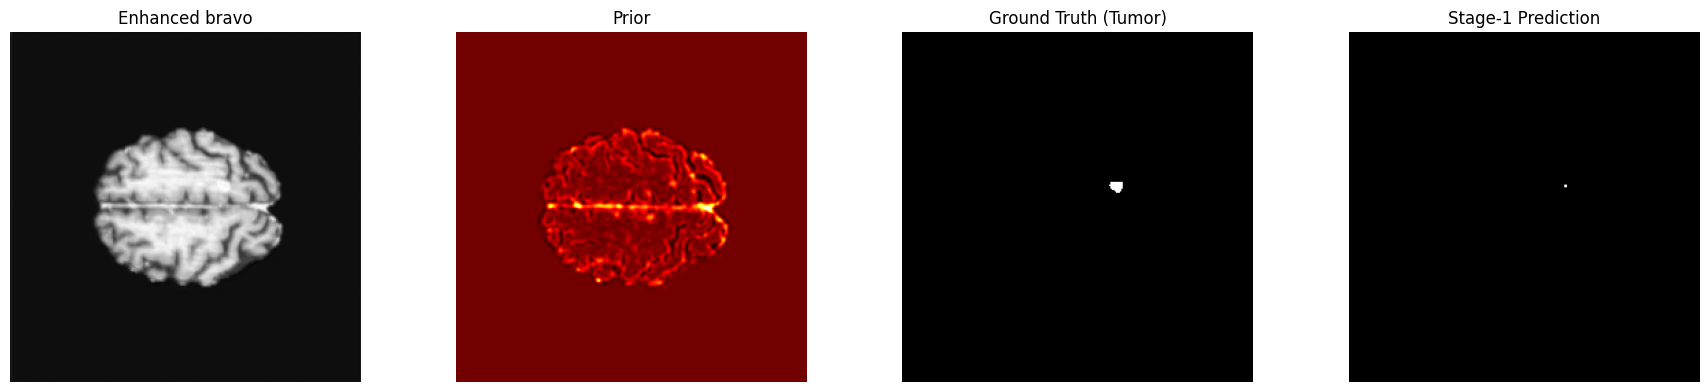

In [ ]:
model1.load_state_dict(torch.load(best_path, map_location=DEVICE))
model1.eval()

chosen_idx = None
for i in range(len(val_ds1)):
    x, y = val_ds1[i]
    if y.sum() > 50:
        chosen_idx = i
        print("Using slice index:", i)
        break

x, y = val_ds1[chosen_idx]

with torch.no_grad():
    logits = model1(x.unsqueeze(0).to(DEVICE))
    prob = torch.sigmoid(logits).squeeze().cpu().numpy()
    pred = (prob > 0.3).astype(np.float32)

plt.figure(figsize=(18, 4))

plt.subplot(1, 4, 1)
plt.imshow(x[0].numpy(), cmap="gray")
plt.title("Enhanced bravo")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(x[4].numpy(), cmap="hot")
plt.title("Prior")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(y[0].numpy(), cmap="gray")
plt.title("Ground Truth (Tumor)")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(pred, cmap="gray")
plt.title("Stage-1 Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

### MC Dropout Uncertainty

In [ ]:
@torch.no_grad()
def mc_dropout_predict(model, x, passes=4):
    model.train()   # keep dropout active
    preds = []

    for _ in range(passes):
        logits = model(x)
        preds.append(torch.sigmoid(logits))

    preds = torch.stack(preds, dim=0)   
    mean_prob = preds.mean(dim=0)
    uncertainty = preds.var(dim=0)

    return mean_prob, uncertainty

In [ ]:
class MetsStage2Dataset(Dataset):
    def __init__(self, records, denoiser, schedule, model1):
        self.records = records
        self.denoiser = denoiser
        self.schedule = schedule
        self.model1 = model1

    def __len__(self):
        return len(self.records)

    @torch.no_grad()
    def __getitem__(self, idx):
        r = self.records[idx]

        bravo  = resize_if_needed(load_grayscale(r["bravo"]),  IMG_SIZE)
        flair  = resize_if_needed(load_grayscale(r["flair"]),  IMG_SIZE)
        t1_gd  = resize_if_needed(load_grayscale(r["t1_gd"]),  IMG_SIZE)
        t1_pre = resize_if_needed(load_grayscale(r["t1_pre"]), IMG_SIZE)
        seg    = resize_if_needed(load_grayscale(r["seg"]),    IMG_SIZE, is_mask=True)

        bravo  = normalize_percentile(bravo)
        flair  = normalize_percentile(flair)
        t1_gd  = normalize_percentile(t1_gd)
        t1_pre = normalize_percentile(t1_pre)
        seg    = to_binary_mask(seg)

        prior = compute_prior_map(bravo, flair, t1_gd, t1_pre)

        x4 = torch.tensor(np.stack([bravo, flair, t1_gd, t1_pre], axis=0), dtype=torch.float32)

        
        xt = x4.unsqueeze(0).to(DEVICE)
        t = torch.full((1,), 8, device=DEVICE, dtype=torch.long)
        pred_noise = self.denoiser(xt, t)
        x4_enh = (xt - 0.15 * pred_noise).squeeze(0).cpu()

        
        prior_t = torch.tensor(prior[None], dtype=torch.float32)
        x1 = torch.cat([x4_enh, prior_t], dim=0).unsqueeze(0).to(DEVICE)

        mean_prob, unc = mc_dropout_predict(self.model1, x1, passes=4)
        mean_prob = mean_prob.squeeze(0).cpu()   
        unc = unc.squeeze(0).cpu()               

        
        feedback = mean_prob * (1 - unc) + 0.5 * prior_t * unc
        feedback = torch.clamp(feedback, 0, 1)

        
        x2 = torch.cat([x4_enh, prior_t, mean_prob, unc, feedback], dim=0)  
        y = torch.tensor(seg[None], dtype=torch.float32)

        return x2, y

In [ ]:
stage2_sample_ds = MetsStage2Dataset(train_records_split[:20], denoiser, schedule, model1)
x2, y2 = stage2_sample_ds[0]

print("Stage-2 sample x shape:", x2.shape)
print("Stage-2 sample y shape:", y2.shape)

Stage-2 sample x shape: torch.Size([8, 256, 256])
Stage-2 sample y shape: torch.Size([1, 256, 256])


In [ ]:
STAGE2_BATCH_SIZE = 2
STAGE2_NUM_WORKERS = 0

# keep it lighter first
train_ds2 = MetsStage2Dataset(train_records_split[:3000], denoiser, schedule, model1)
val_ds2   = MetsStage2Dataset(val_records_split[:800], denoiser, schedule, model1)

train_loader2 = DataLoader(
    train_ds2,
    batch_size=STAGE2_BATCH_SIZE,
    shuffle=True,
    num_workers=STAGE2_NUM_WORKERS,
    pin_memory=True
)

val_loader2 = DataLoader(
    val_ds2,
    batch_size=STAGE2_BATCH_SIZE,
    shuffle=False,
    num_workers=STAGE2_NUM_WORKERS,
    pin_memory=True
)

print("Train stage-2 batches:", len(train_loader2))
print("Val stage-2 batches  :", len(val_loader2))

Train stage-2 batches: 1500
Val stage-2 batches  : 400


### Stage-2 Segmentation

In [ ]:
model2 = SmallUNet(in_ch=8, out_ch=1, base=24, dropout=0.15).to(DEVICE)
opt2 = torch.optim.AdamW(model2.parameters(), lr=2e-4, weight_decay=1e-5)

best_val_dice_2 = -1
best_path2 = "/kaggle/working/best_stage2.pth"
EPOCHS_STAGE2 = 6

In [ ]:
for epoch in range(EPOCHS_STAGE2):
    model2.train()
    train_losses = []
    train_dices = []

    for x, y in train_loader2:
        x, y = x.to(DEVICE), y.to(DEVICE)

        logits = model2(x)
        loss = combined_loss(logits, y)

        opt2.zero_grad()
        loss.backward()
        opt2.step()

        train_losses.append(loss.item())
        train_dices.append(dice_score_from_logits(logits, y, thr=0.3))

    model2.eval()
    val_losses = []
    val_dices = []

    with torch.no_grad():
        for x, y in val_loader2:
            x, y = x.to(DEVICE), y.to(DEVICE)

            logits = model2(x)
            loss = combined_loss(logits, y)

            val_losses.append(loss.item())
            val_dices.append(dice_score_from_logits(logits, y, thr=0.3))

    mean_train_loss = np.mean(train_losses)
    mean_train_dice = np.mean(train_dices)
    mean_val_loss = np.mean(val_losses)
    mean_val_dice = np.mean(val_dices)

    print(
        f"[Stage2] Epoch {epoch+1}/{EPOCHS_STAGE2} | "
        f"Train Loss: {mean_train_loss:.4f} | "
        f"Train Dice: {mean_train_dice:.4f} | "
        f"Val Loss: {mean_val_loss:.4f} | "
        f"Val Dice: {mean_val_dice:.4f}"
    )

    if mean_val_dice > best_val_dice_2:
        best_val_dice_2 = mean_val_dice
        torch.save(model2.state_dict(), best_path2)

print("Best Stage-2 Val Dice:", best_val_dice_2)

[Stage2] Epoch 1/6 | Train Loss: 0.7082 | Train Dice: 0.0800 | Val Loss: 0.6636 | Val Dice: 0.4074
[Stage2] Epoch 2/6 | Train Loss: 0.6048 | Train Dice: 0.2257 | Val Loss: 0.5809 | Val Dice: 0.2973
[Stage2] Epoch 3/6 | Train Loss: 0.5696 | Train Dice: 0.2207 | Val Loss: 0.5590 | Val Dice: 0.3324
[Stage2] Epoch 4/6 | Train Loss: 0.5508 | Train Dice: 0.2452 | Val Loss: 0.5531 | Val Dice: 0.3693
[Stage2] Epoch 5/6 | Train Loss: 0.5449 | Train Dice: 0.2397 | Val Loss: 0.5520 | Val Dice: 0.3544
[Stage2] Epoch 6/6 | Train Loss: 0.5423 | Train Dice: 0.2313 | Val Loss: 0.5510 | Val Dice: 0.3285
Best Stage-2 Val Dice: 0.40735525300074243


Using stage-2 slice index: 103


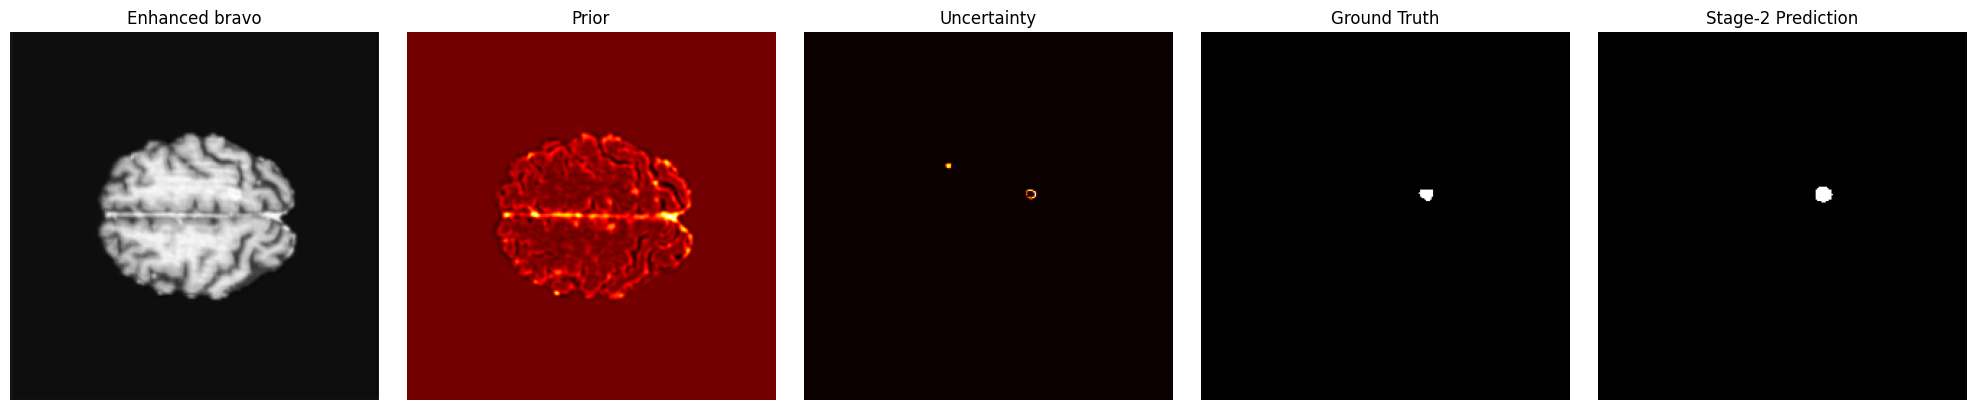

In [ ]:
model2.load_state_dict(torch.load(best_path2, map_location=DEVICE))
model2.eval()

chosen_idx = None
for i in range(len(val_ds2)):
    _, y2 = val_ds2[i]
    if y2.sum() > 50:
        chosen_idx = i
        print("Using stage-2 slice index:", i)
        break

x2, y2 = val_ds2[chosen_idx]

with torch.no_grad():
    logits2 = model2(x2.unsqueeze(0).to(DEVICE))
    prob2 = torch.sigmoid(logits2).squeeze().cpu().numpy()
    pred2 = (prob2 > 0.3).astype(np.float32)

plt.figure(figsize=(20, 4))

plt.subplot(1, 5, 1)
plt.imshow(x2[0].numpy(), cmap="gray")
plt.title("Enhanced bravo")
plt.axis("off")

plt.subplot(1, 5, 2)
plt.imshow(x2[4].numpy(), cmap="hot")
plt.title("Prior")
plt.axis("off")

plt.subplot(1, 5, 3)
plt.imshow(x2[6].numpy(), cmap="hot")
plt.title("Uncertainty")
plt.axis("off")

plt.subplot(1, 5, 4)
plt.imshow(y2[0].numpy(), cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 5, 5)
plt.imshow(pred2, cmap="gray")
plt.title("Stage-2 Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
model1 = SmallUNet(in_ch=5, out_ch=1, base=24, dropout=0.1).to(DEVICE)
opt1 = torch.optim.AdamW(model1.parameters(), lr=2e-4, weight_decay=1e-5)

EPOCHS_STAGE1 = 6
best_val_dice = -1
best_path = "/kaggle/working/best_stage1.pth"

stage1_history = {
    "train_loss": [],
    "train_dice": [],
    "val_loss": [],
    "val_dice": []
}

for epoch in range(EPOCHS_STAGE1):
    model1.train()
    train_losses = []
    train_dices = []

    for x, y in train_loader1:
        x, y = x.to(DEVICE), y.to(DEVICE)

        logits = model1(x)
        loss = combined_loss(logits, y)

        opt1.zero_grad()
        loss.backward()
        opt1.step()

        train_losses.append(loss.item())
        train_dices.append(dice_score_from_logits(logits, y, thr=0.3))

    model1.eval()
    val_losses = []
    val_dices = []

    with torch.no_grad():
        for x, y in val_loader1:
            x, y = x.to(DEVICE), y.to(DEVICE)

            logits = model1(x)
            loss = combined_loss(logits, y)

            val_losses.append(loss.item())
            val_dices.append(dice_score_from_logits(logits, y, thr=0.3))

    mean_train_loss = np.mean(train_losses)
    mean_train_dice = np.mean(train_dices)
    mean_val_loss = np.mean(val_losses)
    mean_val_dice = np.mean(val_dices)

    stage1_history["train_loss"].append(mean_train_loss)
    stage1_history["train_dice"].append(mean_train_dice)
    stage1_history["val_loss"].append(mean_val_loss)
    stage1_history["val_dice"].append(mean_val_dice)

    print(
        f"Epoch {epoch+1}/{EPOCHS_STAGE1} | "
        f"Train Loss: {mean_train_loss:.4f} | "
        f"Train Dice: {mean_train_dice:.4f} | "
        f"Val Loss: {mean_val_loss:.4f} | "
        f"Val Dice: {mean_val_dice:.4f}"
    )

    if mean_val_dice > best_val_dice:
        best_val_dice = mean_val_dice
        torch.save(model1.state_dict(), best_path)

print("Best Val Dice:", best_val_dice)

Epoch 1/6 | Train Loss: 0.6437 | Train Dice: 0.2520 | Val Loss: 0.5856 | Val Dice: 0.3016
Epoch 2/6 | Train Loss: 0.5714 | Train Dice: 0.3575 | Val Loss: 0.5484 | Val Dice: 0.3495
Epoch 3/6 | Train Loss: 0.5539 | Train Dice: 0.4136 | Val Loss: 0.5402 | Val Dice: 0.3531
Epoch 4/6 | Train Loss: 0.5490 | Train Dice: 0.4297 | Val Loss: 0.5374 | Val Dice: 0.4209
Epoch 5/6 | Train Loss: 0.5459 | Train Dice: 0.4539 | Val Loss: 0.5347 | Val Dice: 0.6496
Epoch 6/6 | Train Loss: 0.5438 | Train Dice: 0.4618 | Val Loss: 0.5418 | Val Dice: 0.7799
Best Val Dice: 0.7799040767919083


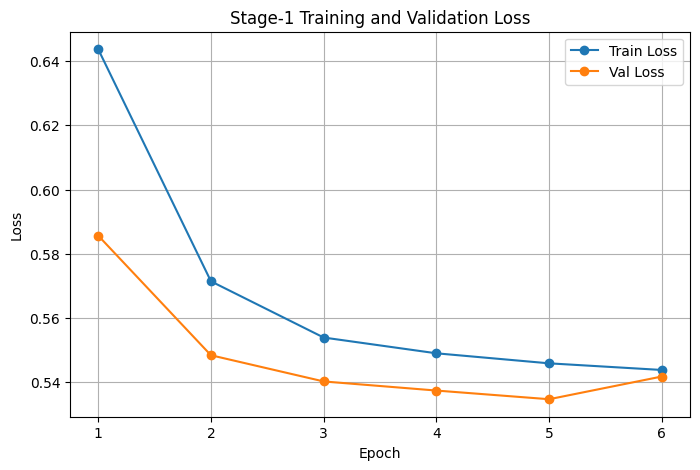

In [ ]:
epochs = list(range(1, len(stage1_history["train_loss"]) + 1))

plt.figure(figsize=(8, 5))
plt.plot(epochs, stage1_history["train_loss"], marker='o', label="Train Loss")
plt.plot(epochs, stage1_history["val_loss"], marker='o', label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stage-1 Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

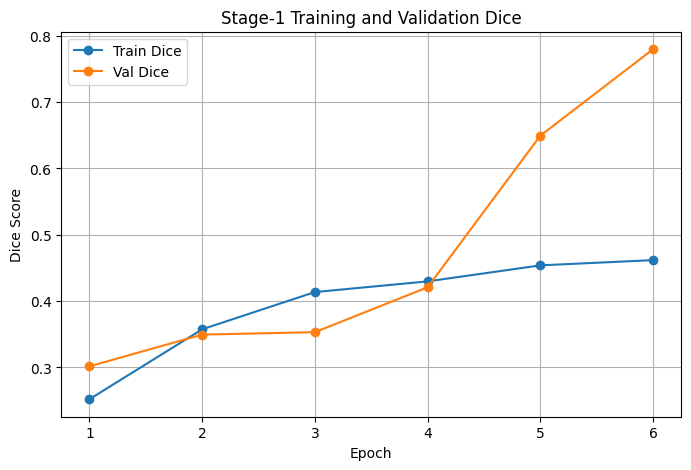

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, stage1_history["train_dice"], marker='o', label="Train Dice")
plt.plot(epochs, stage1_history["val_dice"], marker='o', label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Stage-1 Training and Validation Dice")
plt.legend()
plt.grid(True)
plt.show()

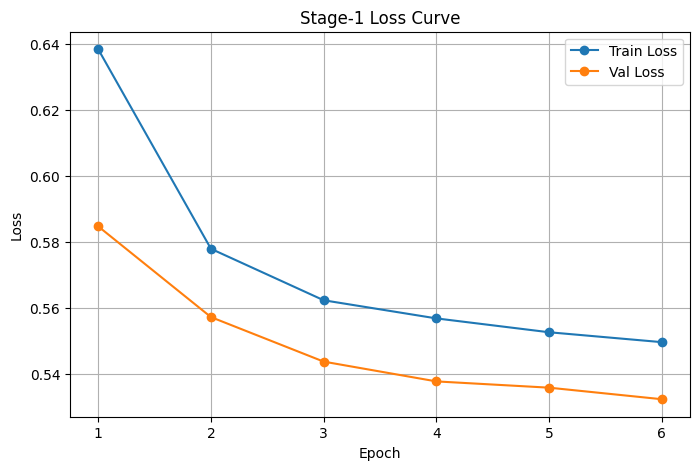

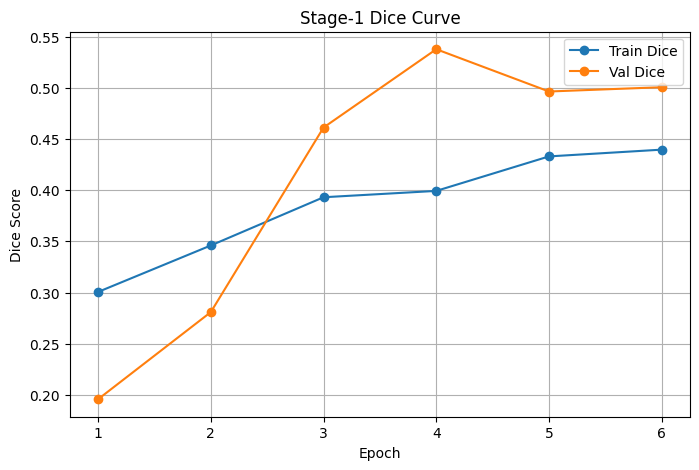

In [ ]:
epochs = [1, 2, 3, 4, 5, 6]

train_loss = [0.6384, 0.5779, 0.5623, 0.5568, 0.5526, 0.5496]
train_dice = [0.3006, 0.3460, 0.3931, 0.3993, 0.4330, 0.4396]
val_loss   = [0.5847, 0.5572, 0.5437, 0.5377, 0.5358, 0.5323]
val_dice   = [0.1958, 0.2809, 0.4612, 0.5377, 0.4964, 0.5006]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, marker='o', label='Train Loss')
plt.plot(epochs, val_loss, marker='o', label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stage-1 Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_dice, marker='o', label='Train Dice')
plt.plot(epochs, val_dice, marker='o', label='Val Dice')
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Stage-1 Dice Curve")
plt.legend()
plt.grid(True)
plt.show()

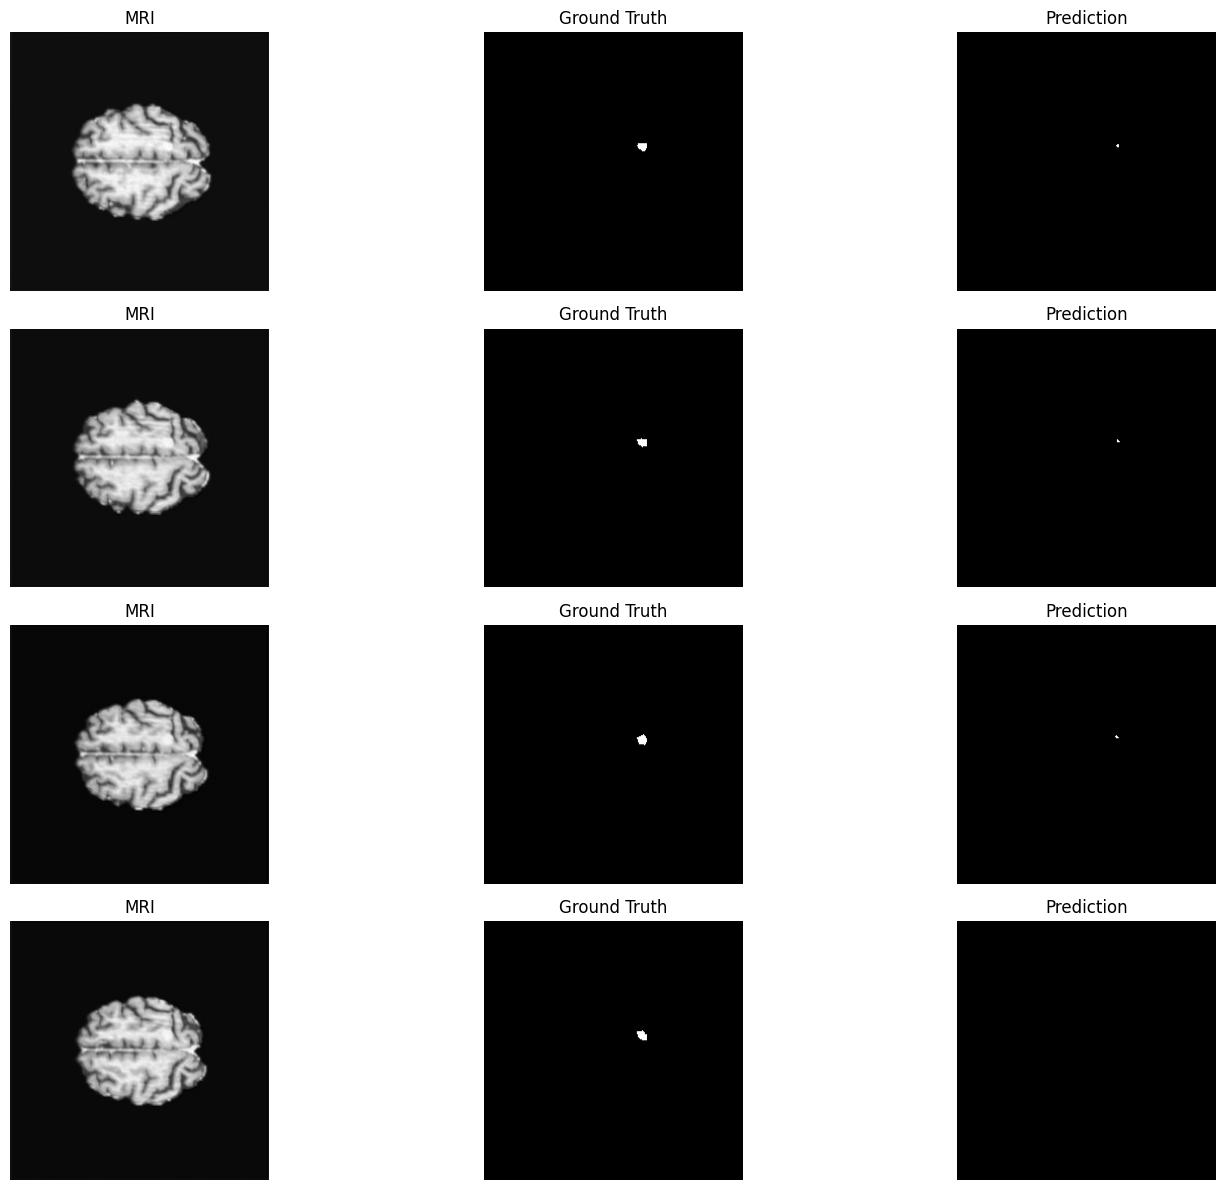

In [ ]:
model1.load_state_dict(torch.load(best_path, map_location=DEVICE))
model1.eval()

count = 0
plt.figure(figsize=(16, 12))

for i in range(len(val_ds1)):
    x, y = val_ds1[i]
    if y.sum() > 50:
        with torch.no_grad():
            logits = model1(x.unsqueeze(0).to(DEVICE))
            prob = torch.sigmoid(logits).squeeze().cpu().numpy()
            pred = (prob > 0.3).astype(np.float32)

        row = count
        plt.subplot(4, 3, row*3 + 1)
        plt.imshow(x[0].numpy(), cmap="gray")
        plt.title("MRI")
        plt.axis("off")

        plt.subplot(4, 3, row*3 + 2)
        plt.imshow(y[0].numpy(), cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(4, 3, row*3 + 3)
        plt.imshow(pred, cmap="gray")
        plt.title("Prediction")
        plt.axis("off")

        count += 1
        if count == 4:
            break

plt.tight_layout()
plt.show()

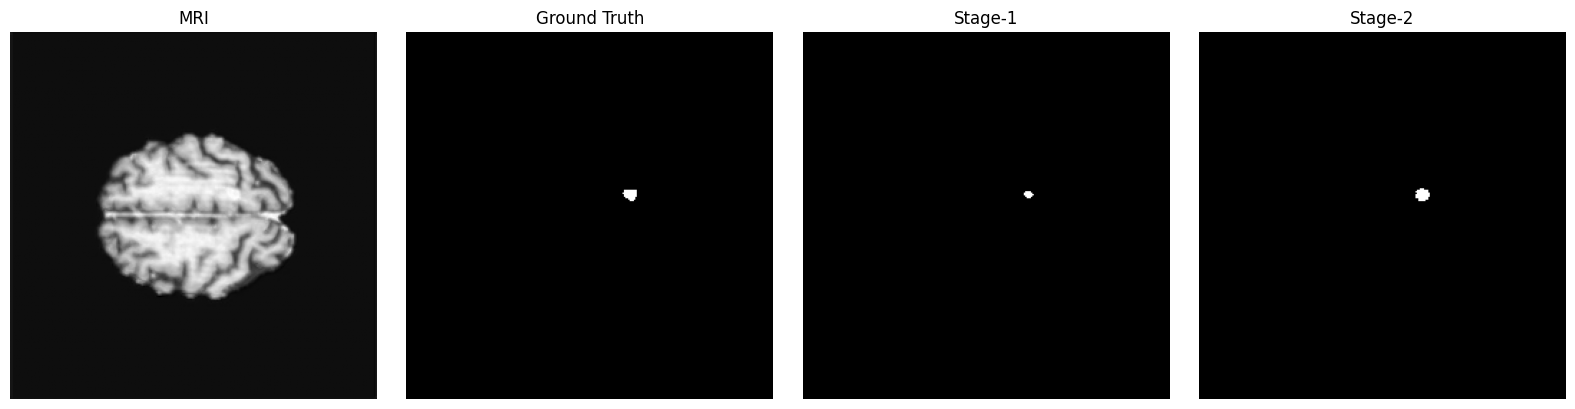

In [ ]:
model1.load_state_dict(torch.load(best_path, map_location=DEVICE))
model2.load_state_dict(torch.load(best_path2, map_location=DEVICE))

model1.eval()
model2.eval()

chosen_idx = None
for i in range(len(val_ds2)):
    _, y2 = val_ds2[i]
    if y2.sum() > 50:
        chosen_idx = i
        break

x2, y2 = val_ds2[chosen_idx]

with torch.no_grad():
    # stage-2 prediction
    logits2 = model2(x2.unsqueeze(0).to(DEVICE))
    pred2 = (torch.sigmoid(logits2).squeeze().cpu().numpy() > 0.3).astype(np.float32)

    # stage-1 probability already present inside x2[5]
    pred1 = (x2[5].numpy() > 0.3).astype(np.float32)

plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.imshow(x2[0].numpy(), cmap="gray")
plt.title("MRI")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(y2[0].numpy(), cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(pred1, cmap="gray")
plt.title("Stage-1")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(pred2, cmap="gray")
plt.title("Stage-2")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def get_confusion_stats_from_logits(logits, targets, thr=0.3):
    probs = torch.sigmoid(logits)
    preds = (probs > thr).float()

    tp = (preds * targets).sum().item()
    tn = ((1 - preds) * (1 - targets)).sum().item()
    fp = (preds * (1 - targets)).sum().item()
    fn = ((1 - preds) * targets).sum().item()

    return tp, tn, fp, fn

def precision_score_from_logits(logits, targets, thr=0.3, eps=1e-6):
    tp, tn, fp, fn = get_confusion_stats_from_logits(logits, targets, thr)
    return tp / (tp + fp + eps)

def recall_score_from_logits(logits, targets, thr=0.3, eps=1e-6):
    tp, tn, fp, fn = get_confusion_stats_from_logits(logits, targets, thr)
    return tp / (tp + fn + eps)

def specificity_score_from_logits(logits, targets, thr=0.3, eps=1e-6):
    tp, tn, fp, fn = get_confusion_stats_from_logits(logits, targets, thr)
    return tn / (tn + fp + eps)

def accuracy_score_from_logits(logits, targets, thr=0.3, eps=1e-6):
    tp, tn, fp, fn = get_confusion_stats_from_logits(logits, targets, thr)
    return (tp + tn) / (tp + tn + fp + fn + eps)

def f1_score_from_logits(logits, targets, thr=0.3, eps=1e-6):
    p = precision_score_from_logits(logits, targets, thr, eps)
    r = recall_score_from_logits(logits, targets, thr, eps)
    return 2 * p * r / (p + r + eps)

In [ ]:
model1.load_state_dict(torch.load(best_path, map_location=DEVICE))
model1.eval()

stage1_metrics = {
    "dice": [],
    "iou": [],
    "precision": [],
    "recall": [],
    "specificity": [],
    "accuracy": [],
    "f1": []
}

with torch.no_grad():
    for x, y in val_loader1:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model1(x)

        stage1_metrics["dice"].append(dice_score_from_logits(logits, y, thr=0.3))
        stage1_metrics["iou"].append(iou_score_from_logits(logits, y, thr=0.3))
        stage1_metrics["precision"].append(precision_score_from_logits(logits, y, thr=0.3))
        stage1_metrics["recall"].append(recall_score_from_logits(logits, y, thr=0.3))
        stage1_metrics["specificity"].append(specificity_score_from_logits(logits, y, thr=0.3))
        stage1_metrics["accuracy"].append(accuracy_score_from_logits(logits, y, thr=0.3))
        stage1_metrics["f1"].append(f1_score_from_logits(logits, y, thr=0.3))

print("Stage-1 Validation Metrics")
for k, v in stage1_metrics.items():
    print(f"{k:12s}: {np.mean(v):.4f}")

Stage-1 Validation Metrics
dice        : 0.7799
iou         : 0.7562
precision   : 0.1715
recall      : 0.1264
specificity : 0.9999
accuracy    : 0.9998
f1          : 0.1336


In [ ]:
model2.load_state_dict(torch.load(best_path2, map_location=DEVICE))
model2.eval()

stage2_metrics = {
    "dice": [],
    "iou": [],
    "precision": [],
    "recall": [],
    "specificity": [],
    "accuracy": [],
    "f1": []
}

with torch.no_grad():
    for x, y in val_loader2:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model2(x)

        stage2_metrics["dice"].append(dice_score_from_logits(logits, y, thr=0.3))
        stage2_metrics["iou"].append(iou_score_from_logits(logits, y, thr=0.3))
        stage2_metrics["precision"].append(precision_score_from_logits(logits, y, thr=0.3))
        stage2_metrics["recall"].append(recall_score_from_logits(logits, y, thr=0.3))
        stage2_metrics["specificity"].append(specificity_score_from_logits(logits, y, thr=0.3))
        stage2_metrics["accuracy"].append(accuracy_score_from_logits(logits, y, thr=0.3))
        stage2_metrics["f1"].append(f1_score_from_logits(logits, y, thr=0.3))

print("Stage-2 Validation Metrics")
for k, v in stage2_metrics.items():
    print(f"{k:12s}: {np.mean(v):.4f}")

Stage-2 Validation Metrics
dice        : 0.4162
iou         : 0.3962
precision   : 0.0592
recall      : 0.1306
specificity : 0.9986
accuracy    : 0.9985
f1          : 0.0731


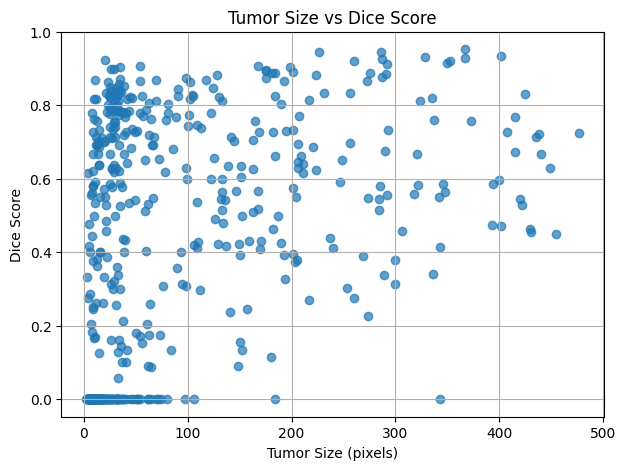

In [ ]:
model1.load_state_dict(torch.load(best_path, map_location=DEVICE))
model1.eval()

tumor_sizes = []
dice_scores = []

with torch.no_grad():
    for i in range(len(val_ds1)):
        x, y = val_ds1[i]
        gt_area = y.sum().item()

        if gt_area > 0:
            logits = model1(x.unsqueeze(0).to(DEVICE))
            d = dice_score_from_logits(logits, y.unsqueeze(0).to(DEVICE), thr=0.3)

            tumor_sizes.append(gt_area)
            dice_scores.append(d)

plt.figure(figsize=(7,5))
plt.scatter(tumor_sizes, dice_scores, alpha=0.7)
plt.xlabel("Tumor Size (pixels)")
plt.ylabel("Dice Score")
plt.title("Tumor Size vs Dice Score")
plt.grid(True)
plt.show()

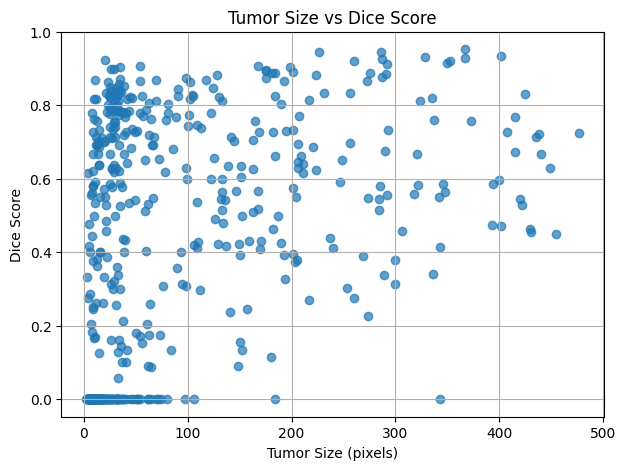

In [ ]:
model1.load_state_dict(torch.load(best_path, map_location=DEVICE))
model1.eval()

tumor_sizes = []
dice_scores = []

with torch.no_grad():
    for i in range(len(val_ds1)):
        x, y = val_ds1[i]
        gt_area = y.sum().item()

        if gt_area > 0:
            logits = model1(x.unsqueeze(0).to(DEVICE))
            d = dice_score_from_logits(logits, y.unsqueeze(0).to(DEVICE), thr=0.3)

            tumor_sizes.append(gt_area)
            dice_scores.append(d)

plt.figure(figsize=(7,5))
plt.scatter(tumor_sizes, dice_scores, alpha=0.7)
plt.xlabel("Tumor Size (pixels)")
plt.ylabel("Dice Score")
plt.title("Tumor Size vs Dice Score")
plt.grid(True)
plt.show()

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2

class GradCAMSegmentation:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.forward_handle = target_layer.register_forward_hook(self.save_activation)
        self.backward_handle = target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def remove_hooks(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

    def generate_cam(self, x, target_mask=None):
        """
        x: input tensor [1, C, H, W]
        target_mask: optional mask [1, 1, H, W]
        """
        self.model.eval()
        self.model.zero_grad()

        logits = self.model(x)   

        if target_mask is None:
            probs = torch.sigmoid(logits)
            target = probs.sum()
        else:
            target = (logits * target_mask).sum()

        target.backward(retain_graph=True)

        grads = self.gradients[0]       
        acts  = self.activations[0]     

        weights = grads.mean(dim=(1, 2), keepdim=True)   
        cam = (weights * acts).sum(dim=0)                
        cam = F.relu(cam)

        cam = cam.cpu().numpy()
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)

        return cam, logits.detach()

In [ ]:
target_layer_stage1 = model1.b
gradcam_stage1 = GradCAMSegmentation(model1, target_layer_stage1)

print("Grad-CAM target layer for Stage-1:", target_layer_stage1)

Grad-CAM target layer for Stage-1: DoubleConv(
  (block): Sequential(
    (0): Conv2d(48, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout2d(p=0.1, inplace=False)
    (4): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
  )
)


Using slice index: 103


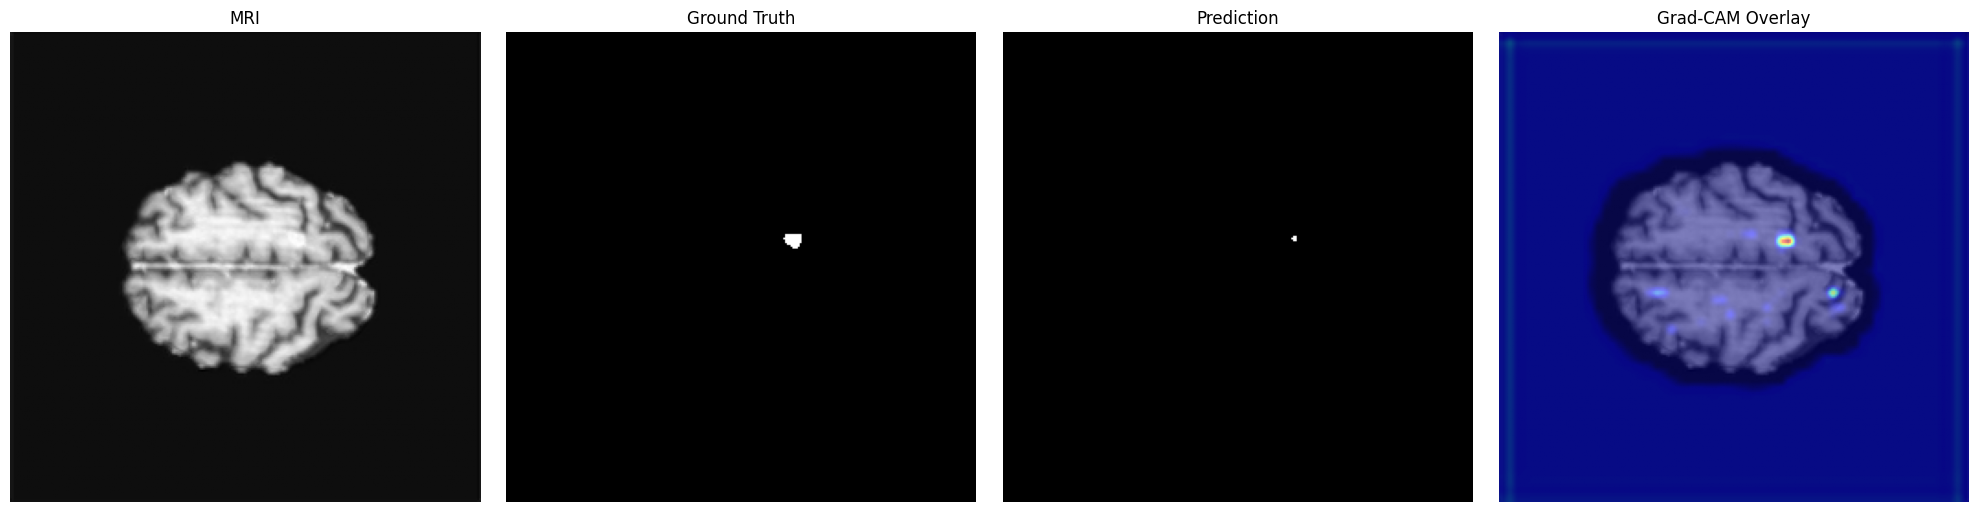

In [ ]:
model1.load_state_dict(torch.load(best_path, map_location=DEVICE))
model1.eval()

chosen_idx = None
for i in range(len(val_ds1)):
    x, y = val_ds1[i]
    if y.sum() > 50:
        chosen_idx = i
        print("Using slice index:", i)
        break

x, y = val_ds1[chosen_idx]

x_in = x.unsqueeze(0).to(DEVICE)
y_in = y.unsqueeze(0).to(DEVICE)

cam, logits = gradcam_stage1.generate_cam(x_in, target_mask=y_in)

prob = torch.sigmoid(logits).squeeze().cpu().numpy()
pred = (prob > 0.3).astype(np.float32)

mri = x[0].numpy()
gt = y[0].numpy()

cam_resized = cv2.resize(cam, (mri.shape[1], mri.shape[0]))

plt.figure(figsize=(20,5))

plt.subplot(1,4,1)
plt.imshow(mri, cmap="gray")
plt.title("MRI")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(gt, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(pred, cmap="gray")
plt.title("Prediction")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(mri, cmap="gray")
plt.imshow(cam_resized, cmap="jet", alpha=0.5)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

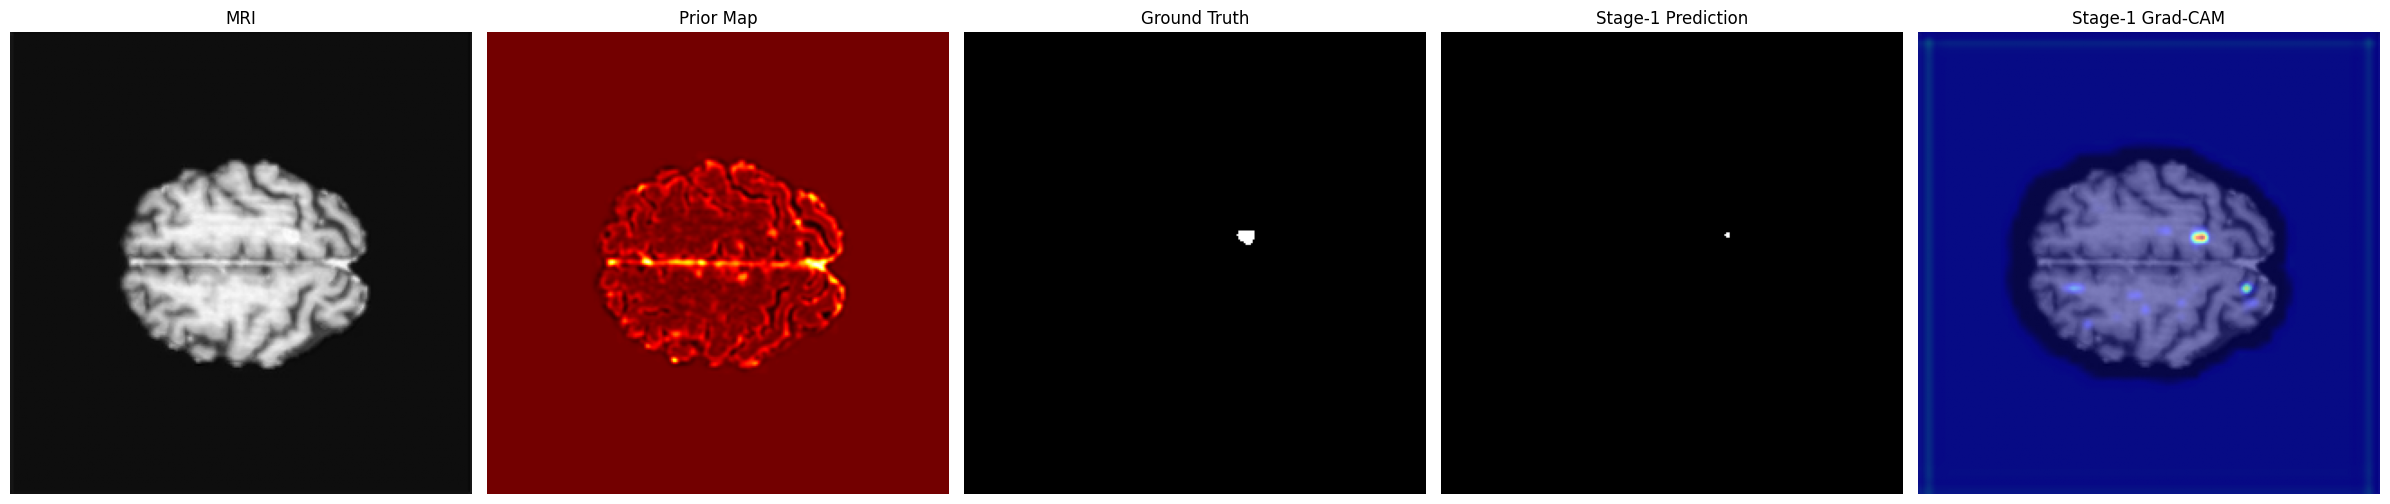

In [ ]:
plt.figure(figsize=(24,5))

plt.subplot(1,5,1)
plt.imshow(mri, cmap="gray")
plt.title("MRI")
plt.axis("off")

plt.subplot(1,5,2)
plt.imshow(x[4].numpy(), cmap="hot")
plt.title("Prior Map")
plt.axis("off")

plt.subplot(1,5,3)
plt.imshow(gt, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,5,4)
plt.imshow(pred, cmap="gray")
plt.title("Stage-1 Prediction")
plt.axis("off")

plt.subplot(1,5,5)
plt.imshow(mri, cmap="gray")
plt.imshow(cam_resized, cmap="jet", alpha=0.5)
plt.title("Stage-1 Grad-CAM")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
target_layer_stage2 = model2.b
gradcam_stage2 = GradCAMSegmentation(model2, target_layer_stage2)

print("Grad-CAM target layer for Stage-2:", target_layer_stage2)

Grad-CAM target layer for Stage-2: DoubleConv(
  (block): Sequential(
    (0): Conv2d(48, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout2d(p=0.15, inplace=False)
    (4): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
  )
)


Using stage-2 slice index: 103


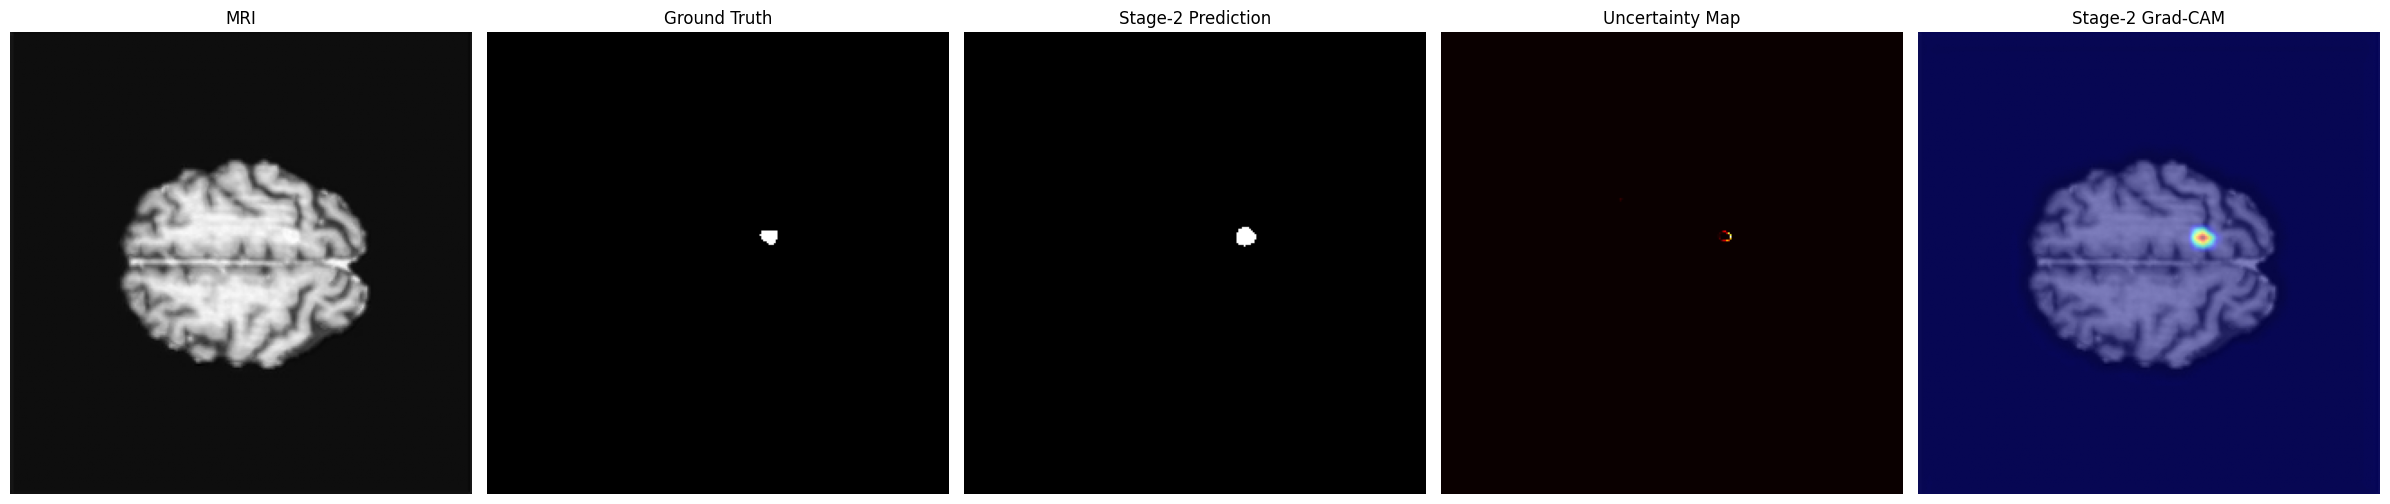

In [ ]:
model2.load_state_dict(torch.load(best_path2, map_location=DEVICE))
model2.eval()

chosen_idx = None
for i in range(len(val_ds2)):
    x2, y2 = val_ds2[i]
    if y2.sum() > 50:
        chosen_idx = i
        print("Using stage-2 slice index:", i)
        break

x2, y2 = val_ds2[chosen_idx]

x2_in = x2.unsqueeze(0).to(DEVICE)
y2_in = y2.unsqueeze(0).to(DEVICE)

cam2, logits2 = gradcam_stage2.generate_cam(x2_in, target_mask=y2_in)

prob2 = torch.sigmoid(logits2).squeeze().cpu().numpy()
pred2 = (prob2 > 0.3).astype(np.float32)

mri2 = x2[0].numpy()
gt2 = y2[0].numpy()
unc2 = x2[6].numpy()

cam2_resized = cv2.resize(cam2, (mri2.shape[1], mri2.shape[0]))

plt.figure(figsize=(24,5))

plt.subplot(1,5,1)
plt.imshow(mri2, cmap="gray")
plt.title("MRI")
plt.axis("off")

plt.subplot(1,5,2)
plt.imshow(gt2, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,5,3)
plt.imshow(pred2, cmap="gray")
plt.title("Stage-2 Prediction")
plt.axis("off")

plt.subplot(1,5,4)
plt.imshow(unc2, cmap="hot")
plt.title("Uncertainty Map")
plt.axis("off")

plt.subplot(1,5,5)
plt.imshow(mri2, cmap="gray")
plt.imshow(cam2_resized, cmap="jet", alpha=0.5)
plt.title("Stage-2 Grad-CAM")
plt.axis("off")

plt.tight_layout()
plt.show()

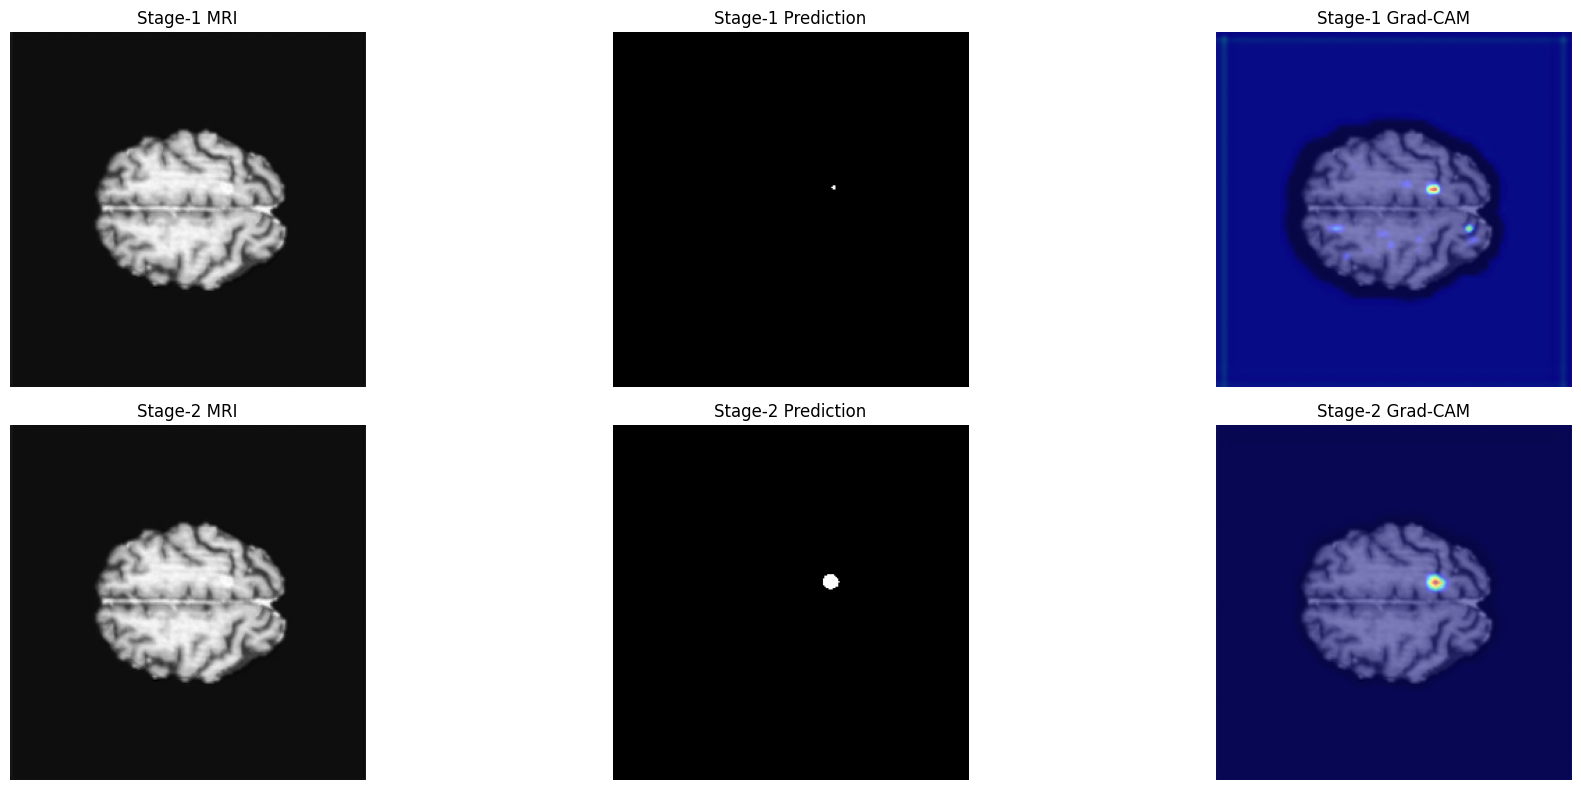

In [ ]:
chosen_idx1 = None
for i in range(len(val_ds1)):
    x, y = val_ds1[i]
    if y.sum() > 50:
        chosen_idx1 = i
        break

x, y = val_ds1[chosen_idx1]
cam1, logits1 = gradcam_stage1.generate_cam(x.unsqueeze(0).to(DEVICE), target_mask=y.unsqueeze(0).to(DEVICE))
pred1 = (torch.sigmoid(logits1).squeeze().cpu().numpy() > 0.3).astype(np.float32)
cam1 = cv2.resize(cam1, (x[0].shape[1], x[0].shape[0]))

chosen_idx2 = None
for i in range(len(val_ds2)):
    x2, y2 = val_ds2[i]
    if y2.sum() > 50:
        chosen_idx2 = i
        break

x2, y2 = val_ds2[chosen_idx2]
cam2, logits2 = gradcam_stage2.generate_cam(x2.unsqueeze(0).to(DEVICE), target_mask=y2.unsqueeze(0).to(DEVICE))
pred2 = (torch.sigmoid(logits2).squeeze().cpu().numpy() > 0.3).astype(np.float32)
cam2 = cv2.resize(cam2, (x2[0].shape[1], x2[0].shape[0]))

plt.figure(figsize=(20,8))

plt.subplot(2,3,1)
plt.imshow(x[0].numpy(), cmap="gray")
plt.title("Stage-1 MRI")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(pred1, cmap="gray")
plt.title("Stage-1 Prediction")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(x[0].numpy(), cmap="gray")
plt.imshow(cam1, cmap="jet", alpha=0.5)
plt.title("Stage-1 Grad-CAM")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(x2[0].numpy(), cmap="gray")
plt.title("Stage-2 MRI")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(pred2, cmap="gray")
plt.title("Stage-2 Prediction")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(x2[0].numpy(), cmap="gray")
plt.imshow(cam2, cmap="jet", alpha=0.5)
plt.title("Stage-2 Grad-CAM")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def normalize_cam(cam):
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    return cam

def cam_to_binary(cam, thr=0.5):
    return (cam > thr).astype(np.float32)

In [ ]:
def cam_iou(cam, gt, thr=0.5, eps=1e-6):
    cam_bin = cam_to_binary(cam, thr)
    inter = (cam_bin * gt).sum()
    union = cam_bin.sum() + gt.sum() - inter
    return inter / (union + eps)

def cam_dice(cam, gt, thr=0.5, eps=1e-6):
    cam_bin = cam_to_binary(cam, thr)
    inter = (cam_bin * gt).sum()
    return (2 * inter) / (cam_bin.sum() + gt.sum() + eps)

In [ ]:
def pointing_game(cam, gt):
    h, w = cam.shape
    max_idx = np.argmax(cam)
    y = max_idx // w
    x = max_idx % w

    return 1 if gt[y, x] > 0 else 0

In [ ]:
def cam_energy_inside(cam, gt, eps=1e-6):
    total_energy = cam.sum() + eps
    tumor_energy = (cam * gt).sum()
    return tumor_energy / total_energy

In [ ]:
model1.eval()

iou_scores = []
dice_scores = []
pointing_scores = []
energy_scores = []

count = 0

for i in range(len(val_ds1)):
    x, y = val_ds1[i]
    gt = y[0].numpy()

    if gt.sum() == 0:
        continue

    x_in = x.unsqueeze(0).to(DEVICE)
    y_in = y.unsqueeze(0).to(DEVICE)

    cam, _ = gradcam_stage1.generate_cam(x_in, target_mask=y_in)
    cam = normalize_cam(cam)

    # IMPORTANT: resize CAM to GT size
    cam = cv2.resize(cam, (gt.shape[1], gt.shape[0]))
    cam = normalize_cam(cam)

    iou_scores.append(cam_iou(cam, gt, thr=0.5))
    dice_scores.append(cam_dice(cam, gt, thr=0.5))
    pointing_scores.append(pointing_game(cam, gt))
    energy_scores.append(cam_energy_inside(cam, gt))

    count += 1
    if count > 200:
        break

print("Grad-CAM Evaluation (Stage-1)")
print("IoU           :", np.mean(iou_scores))
print("Dice          :", np.mean(dice_scores))
print("Pointing Acc  :", np.mean(pointing_scores))
print("Energy inside :", np.mean(energy_scores))

Grad-CAM Evaluation (Stage-1)
IoU           : 0.2551588
Dice          : 0.3606516
Pointing Acc  : 0.5920398009950248
Energy inside : 0.011158632
